Analyze time-series fluorescence data from PURE (Protein synthesis Using Recombinant Elements) experiments. 

## Setup 

In [1]:
!pip install nucleus-cdk==0.5.0rc2 | tail -n2

In [2]:
%load_ext autoreload
%autoreload 2
    
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import the cdk platereader module
from cdk.analysis.cytosol import platereader as pr

# Set up plotting
pr.plot_setup()

## Load Data

In [3]:
# Specify file paths
data_file = "20260123-cytation3-pure-timecourse-gfp-OnePotPURE-Opt4-biotek-cdk.txt"
platemap_file = "20260123-OnePotPURE-Opt4-Platemap_edited.csv"

# Load data
data, platemap = pr.load_platereader_data(
    data_file=data_file,
    platemap_file=platemap_file,
    platereader="biotek-cdk"  # Options: "cytation", "envision", "biotek-cdk"
)

# Checkout first few rows
data.head()

,Time,Well,Data,Row,Column,Read,Clock Time,Date,Experiment Name,Name,...,tRNA Vol (uL),DNA Vol (uL),RNase Inhib Vol (uL),CP Vol (uL),PPK Vol (uL),polyP Vol (uL),Mg-Ace Vol (uL),PEG Vol (uL),Water vol (uL),Rxn Volume (uL)
0,0 days 00:00:00,H14,45,H,14,GFP-F-G35,2026-01-23 14:21:44,20260123,OnePot-Optimization4,14 mM Mg + 3.24 uM Ribo,...,1.00,0.24,0.50,0.30,NaN,NaN,0.30,0.50,0.70,10
1,0 days 00:05:00,H14,42,H,14,GFP-F-G35,2026-01-23 14:26:44,20260123,OnePot-Optimization4,14 mM Mg + 3.24 uM Ribo,...,1.00,0.24,0.50,0.30,NaN,NaN,0.30,0.50,0.70,10
2,0 days 00:10:00,H14,42,H,14,GFP-F-G35,2026-01-23 14:31:44,20260123,OnePot-Optimization4,14 mM Mg + 3.24 uM Ribo,...,1.00,0.24,0.50,0.30,NaN,NaN,0.30,0.50,0.70,10
3,0 days 00:15:00,H14,49,H,14,GFP-F-G35,2026-01-23 14:36:44,20260123,OnePot-Optimization4,14 mM Mg + 3.24 uM Ribo,...,1.00,0.24,0.50,0.30,NaN,NaN,0.30,0.50,0.70,10
4,0 days 00:20:00,H14,330,H,14,GFP-F-G35,2026-01-23 14:41:44,20260123,OnePot-Optimization4,14 mM Mg + 3.24 uM Ribo,...,1.00,0.24,0.50,0.30,NaN,NaN,0.30,0.50,0.70,10


In [4]:
data[data["Sample Type"] == "Control"]["Name"].unique()

array(['PURExpress Control'], dtype=object)

## Plot Raw Curves

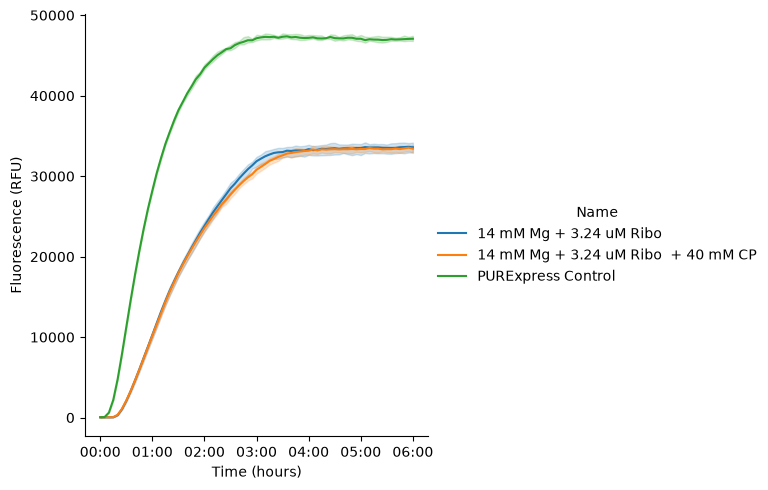

In [5]:
#| label: fig:kinetics-opt4
pr.plot_curves(data=data)

## Normalize Data

In [6]:
# No HPTS/fluorescein normalization control present in this platemap's Name column - skipping normalize_data_to_controls, using raw (unnormalized) data

Now replot your curves to see them normalized

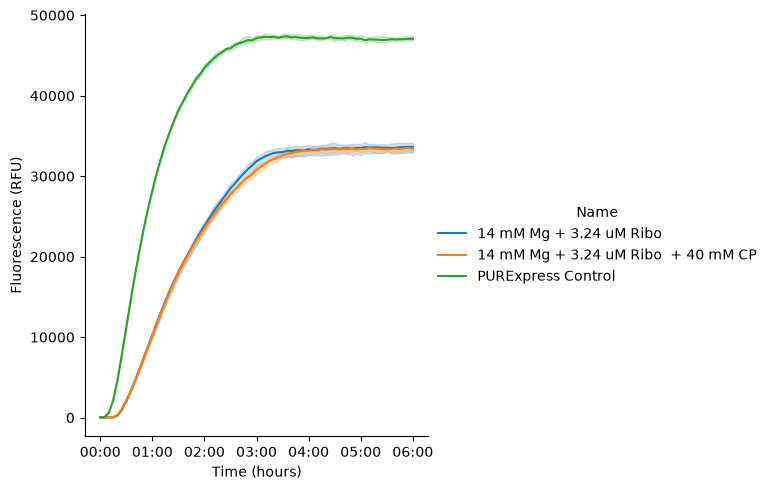

In [7]:
g = pr.plot_curves(data=data)

## Kinetic Analysis
**Metrics extracted:**

  - **Vmax** (`Velocity Max`): Maximum rate of fluorescence increase (slope at inflection point)
  - **Lag time**: Time to reach the exponential phase
  - **Steady-state**: Final fluorescence level and time to reach 95% of asymptote
  - **Drift**: Rate of signal decay or increase after steady-state
  - **R²**: Goodness of fit

In [8]:
# Perform kinetic analysis using sigmoid_drift model
kinetics = pr.kinetic_analysis(
    data=data,
    group_by=['Name'],  # Group by experimental condition
)

kinetics.head()

PROVIDING AVERAGED KINETICS


Velocity           \
                                                         Time     Data   
Name                                                                     
14 mM Mg + 3.24 uM Ribo             0 days 01:18:51.660659279 16823.96   
14 mM Mg + 3.24 uM Ribo  + 40 mM CP 0 days 01:16:59.566756907 16753.06   
PURExpress Control                  0 days 00:48:03.116185365 23684.71   

                                                                   Lag  \
                                         Max                      Time   
Name                                                                     
14 mM Mg + 3.24 uM Ribo             16050.33 0 days 00:15:57.801682726   
14 mM Mg + 3.24 uM Ribo  + 40 mM CP 15284.45 0 days 00:11:13.487683610   
PURExpress Control                  34620.10 0 days 00:07:00.173829854   

                                                         Steady State  \
                                       Data                      Time   
Name                                                                    
14 mM Mg + 3.24 uM Ribo             1119.72 0 days 02:51:27.609394596   
14 mM Mg + 3.24 uM Ribo  + 40 mM CP  432.47 0 days 02:53:49.061275205   
PURExpress Control                  2217.91 0 days 01:48:29.107922329   

                                              \
                                        Data   
Name                                           
14 mM Mg + 3.24 uM Ribo             31965.53   
14 mM Mg + 3.24 uM Ribo  + 40 mM CP 31830.82   
PURExpress Control                  45000.94   

                                                                                   Fit  \
                                                                                params   
Name                                                                                     
14 mM Mg + 3.24 uM Ribo              [33647.92166082343, 1.9079062001189888, 1.3143...   
14 mM Mg + 3.24 uM Ribo  + 40 mM CP  [33506.12816735226, 1.8246182506414312, 1.2832...   
PURExpress Control                   [47369.412249830995, 2.9233670129001106, 0.800...   

                                                 
                                     R^2  drift  
Name                                             
14 mM Mg + 3.24 uM Ribo             1.00 615.24  
14 mM Mg + 3.24 uM Ribo  + 40 mM CP 1.00 737.24  
PURExpress Control                  1.00 706.18

## Visualize Fits on Individual Wells

(<seaborn.axisgrid.FacetGrid at 0x13f5e9bd0>,
                                                      Velocity           \
                                                          Time     Data   
 Name                                                                     
 14 mM Mg + 3.24 uM Ribo             0 days 01:18:51.660659279 16823.96   
 14 mM Mg + 3.24 uM Ribo  + 40 mM CP 0 days 01:16:59.566756907 16753.06   
 PURExpress Control                  0 days 00:48:03.116185365 23684.71   
 
                                                                    Lag  \
                                          Max                      Time   
 Name                                                                     
 14 mM Mg + 3.24 uM Ribo             16050.33 0 days 00:15:57.801682726   
 14 mM Mg + 3.24 uM Ribo  + 40 mM CP 15284.45 0 days 00:11:13.487683610   
 PURExpress Control                  34620.10 0 days 00:07:00.173829854   
 
                                                  

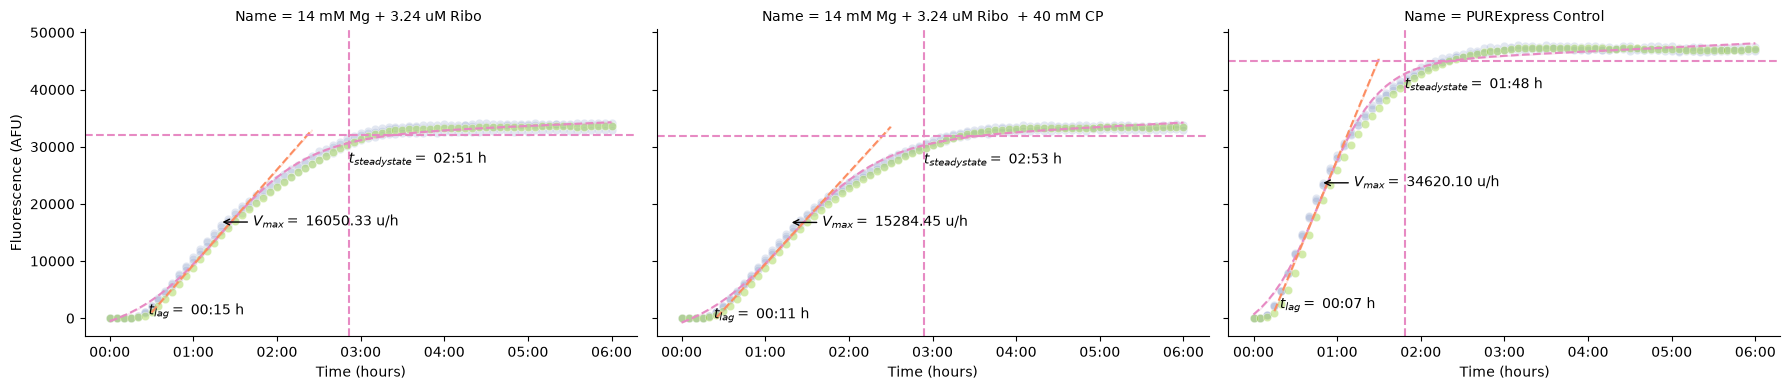

In [9]:
# Plot kinetic fits 
pr.plot_kinetics(data, kinetics=kinetics, group_by=["Name"])

## Summary Plots

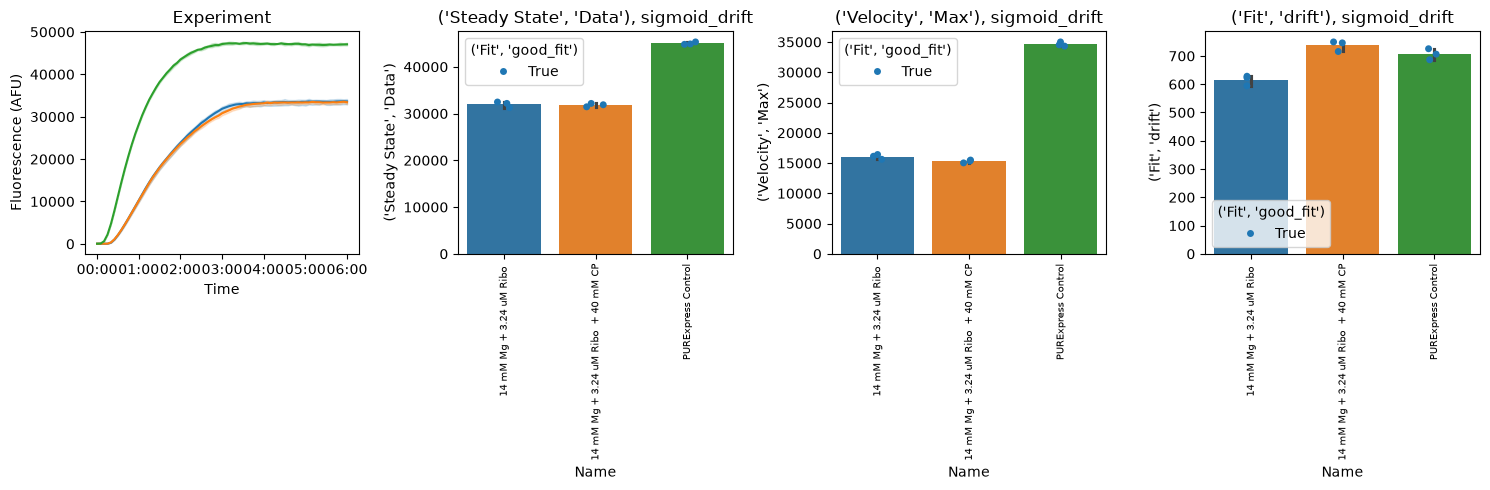

In [10]:
pr.plot_summary(data)

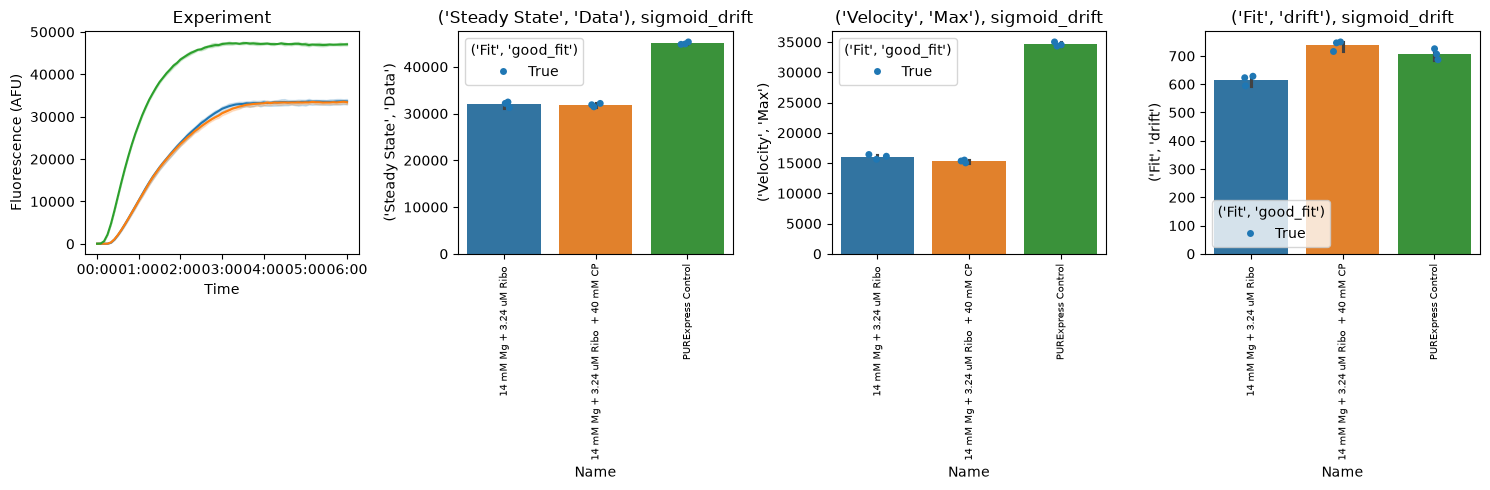

<Figure size 640x480 with 0 Axes>

In [11]:
pr.plot_summary(data)
plt.savefig("summary-normalized.png", bbox_inches='tight')

---

## Key Metrics Explained

### 1. **Steady-State Level** (`Steady State, Data`)
- The final fluorescence value reached by the reaction
- Represents the total amount of protein produced
- Higher values indicate greater expression yield

### 2. **Maximum Velocity** (`Velocity, Max`)
- The steepest slope of the fluorescence curve (at the inflection point)
- Units: RFU per second
- Reflects the peak rate of protein synthesis
- Sensitive to enzyme activity, substrate availability, and reaction conditions

### 3. **Lag Time** (`Lag, Time`)
- Time before exponential fluorescence increase begins
- May reflect time for ribosome assembly or initial translation steps
- Shorter lag times suggest faster reaction initiation

### 4. **Drift** (`Fit, drift`)
- Rate of fluorescence change after reaching steady-state
- Positive drift: continued synthesis or aggregation
- Negative drift: photobleaching, protein degradation, or quenching
- Units: RFU per second

### 5. **R² Value** (`Fit, R^2`)
- Goodness of fit (0 to 1, higher is better)
- R² > 0.98 indicates excellent fit
- Poor fits may indicate noisy data, overflow errors, or non-sigmoid kinetics

---

## Tips and Troubleshooting

- **Overflow errors:** Wells with `OVRFLW` or `NaN` values are automatically excluded from fitting
- **Poor fits (low R²):** Inspect raw curves for anomalies (bubbles, evaporation, pipetting errors)
- **Drift:** Sometimes seen in kinetics curves; use `sigmoid_drift` model
- **Multiple replicates:** Always include technical replicates and report error bars
- **Comparing conditions:** Normalize or blank data consistently across all samples

---

## Next Steps

- Export kinetics results: `pr.export_kinetics(kinetics, 'results.csv')`
- Statistical analysis: Use `scipy.stats` or `statsmodels` for ANOVA/t-tests
- Parameter optimization: Vary Mg²⁺, K⁺, or other conditions to maximize Vmax or steady-state
- Mechanistic modeling: Fit ODE models to extract biological rate constants